In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

In [4]:
## Document Load
PDFloader = PyPDFLoader("../data/KedarkanthaKotgaonItinerary.pdf")
docs = PDFloader.load()

## split - Chunks
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
docs = splitter.split_documents(docs)

## embeddings and vector DB
embed = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embed
)

In [5]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [6]:
class RagState(BaseModel):
    question: str = Field(description="User Question")
    documents : list = []
    context : str = Field(description="Context Data for user question", default="")
    answer : str = Field(description="Final Answer...", default="")

In [7]:
# question -> retrieve -> context -> generate -> end

def retrieve_node(state:RagState) -> RagState:
    docs = vector_store.similarity_search(query=state.question)
    state.documents = docs
    return state
  

def create_context(state:RagState) -> RagState:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"
    state.context = context
    return state
  

def generate_node(state:RagState) -> RagState:
    prompt = f"""
    You are an assistant and provide the answer for user question based on the provided context.
        If you don't find the relevant answer, then just say 'I dont know.'.
        Context is: {state.context},
        Questions is: {state.question}
    """
    res = llm.invoke(prompt)
    state.answer = res.content
    return state

In [8]:
graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context", create_context)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, "retrieve_node")
graph.add_edge("retrieve_node", "create_context")
graph.add_edge("create_context", "generate_node")
graph.add_edge("generate_node", END)

graph = graph.compile()

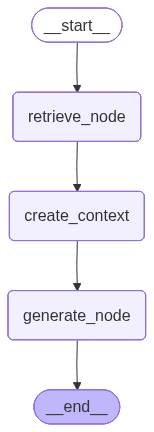

In [10]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [13]:
res = graph.invoke({"question":"What is it safe?"})

In [14]:
print(res["answer"])

The Kedarkantha trek is considered safe for most people—especially those who are fit, have a moderate fitness level, and fall within the 8‑to‑62‑year age range. It’s marketed as a “beginner” trek with easy‑moderate difficulty, so it’s suitable for those who can jog 5 km in 38 minutes and handle a maximum altitude of about 12,500 ft. As with any high‑altitude trek, safety depends on:

- **Physical fitness** – you should be in good shape and able to keep a steady pace.  
- **Proper gear** – trekking poles, layered clothing, sun protection, and a good pair of boots.  
- **Weather awareness** – conditions can change quickly, so keep an eye on forecasts and be prepared for sudden cold or rain.  
- **Guided support** – the trek is organized with a base camp, accommodation, and a licensed guide, which adds an extra layer of safety.  

If you meet the age and fitness criteria, follow the trek’s guidelines, and stay alert to weather and trail conditions, the Kedarkantha trek is generally consid